# Nuclear Statistical Equilibrium

In [1]:
import pynucastro as pyna
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
warnings.filterwarnings('ignore')

In [2]:
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 22
MAJOR_TICK_SIZE = 5
MINOR_TICK_SIZE = 3

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('xtick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('xtick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rc('ytick.major', size=MAJOR_TICK_SIZE, width=1.5)
plt.rc('ytick.minor', size=MINOR_TICK_SIZE, width=1)
plt.rcParams.update({'lines.linewidth': 2.5})

## Constructing the network

Let's recreate the aprox13 network following `aprox13.ipynb`, but using rates from the `StarLib` library instead of `ReacLib` this time.

In [3]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"], 
                          main_library="starlib")

Note that all reverse rates were automatically recomputed using the built-in `DerivedRate` class to ensure NSE compatibility.

We can make additional approximations such as $(\alpha,p)(p, \gamma)$, $(n, \gamma)(n, \gamma)$ and C12 and O16 burning approximations.

In [4]:
net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

net.make_nn_g_approx(intermediate_nuclei=["fe53"])
net.remove_nuclei(["fe53"])

net.make_CO_burning_approx(root_nuclei="C")
net.remove_nuclei(["na23"])
net.make_CO_burning_approx(root_nuclei="CO")
net.remove_nuclei(["al27"])
net.make_CO_burning_approx(root_nuclei="O")
net.remove_nuclei(["p31"])

We now have the same `aprox13` network, but this time using rates from `Starlib` library.

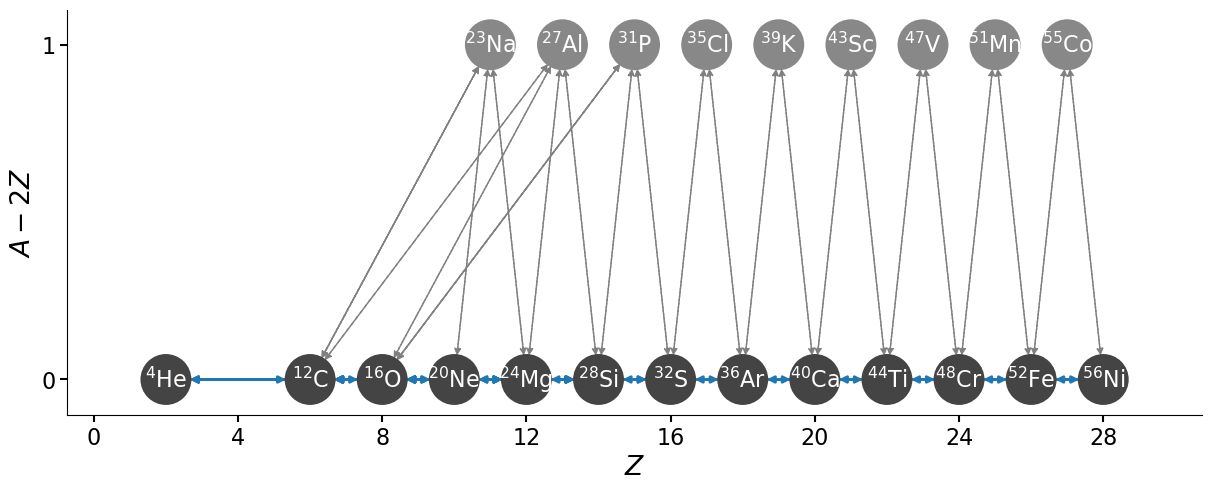

In [5]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1200, 500), node_size=1200, node_font_size=16)

We can look at some properties have the reaction network that we created via the `summary()` method. 
It also checks whether the network is intrinsically compatible with NSE. 

In [6]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 13
  approximated-out nuclei: 9
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 104

  rates explicitly connecting nuclei: 38
  hidden rates: 66

  reaclib rates: 0
  starlib rates: 37
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 30
  derived rates: 37
  modified rates: 0
  custom rates: 0


You can explicitly call the `is_NSE_compatible()` method to see whether the network is compatible with NSE. This method checks
whether all the nuclei are sufficiently connected and whether all rates have a corresponding inverse rate computed from detailed-balance.

In [7]:
net.is_NSE_compatible(verbose=True)

NSE Compatibility Summary 
-------------------------
  Nullity: 1
  Rank: 12
  Max allowed dimension: 1
  Number of species: 13



np.True_

## Integration

Now we want to integrate to steady state. Let's use an uniform initial composition. We will use a tight tolerance close to machine precision to show case machine precision compatibility.

In [8]:
np.random.seed(1234)

In [9]:
net.unsample()

In [10]:
rho = 1e7
T = 6e9
sl_sol = net.integrate_network(tmax=1.e-1, rho=rho, T=T, initial_comp="uniform", 
                            screen_method="potekhin_1998", rtol=1.e-12, atol=1.e-12)

Let's resample the rate and integrate. 

In [11]:
data = []
nsamples = 15
for seed in np.random.randint(0, 1000, nsamples):
    net.resample(seed=seed)
    sol = net.integrate_network(tmax=1.e-1, rho=rho, T=T, initial_comp="uniform", 
                                screen_method="potekhin_1998", rtol=1.e-12, atol=1.e-12)
    data.append(sol)

Now let's solve for the corresponding NSE-state and see how it compares to the steady state solution.

In [12]:
# Create the NSENetwork
nse_net = pyna.NSENetwork(rates=net.get_rates())

# Compute electron fraction assuming uniform composition.
# This is to avoid numerical error deviating from the initial electron fraction
ye = sum(nuc.Z / nuc.A for i, nuc in enumerate(net.unique_nuclei)) / len(net.unique_nuclei)

# Compute the NSE state
nse_comp = nse_net.get_comp_nse(rho, T, ye, init_guess=(-3.5, -14.0), use_coulomb_corr=True, tol=1e-12)

# Visualization of Results

The following code evaluates solutions with sampled rates at consistent time stamps, finds the minimum and maximum value for each relevant mass fraction at each time stamp across solutions, and illustrates the spread in mass fraction given the rate sampling.

In [13]:
ts = np.logspace(-13, -1, num=500)
X_min = np.zeros((len(sl_sol.unique_nuclei), len(ts)))
X_max = np.zeros((len(sl_sol.unique_nuclei), len(ts)))

for i, t in enumerate(ts):
    _Xmin = np.ones(len(sol.unique_nuclei))
    _Xmax = np.zeros(len(sol.unique_nuclei))
    for sol in data:
        X = sol.X_at(t)
        _Xmin[:] = np.minimum(_Xmin, X)
        _Xmax[:] = np.maximum(_Xmax, X)
    X_min[:, i] = _Xmin[:]
    X_max[:, i] = _Xmax[:]

We can plot to see how the species mass fractions evolve over time. We see that the evolution reaches a steady state in the end, indicated by the flat lines. We also see that the steady state solution is independent of the sampled rates. This is because at equilibrium,
the ratio of the forward and reverse rates are always fixed based on the properties of the reactants and products after re-deriving the inverse rate using detailed balance.

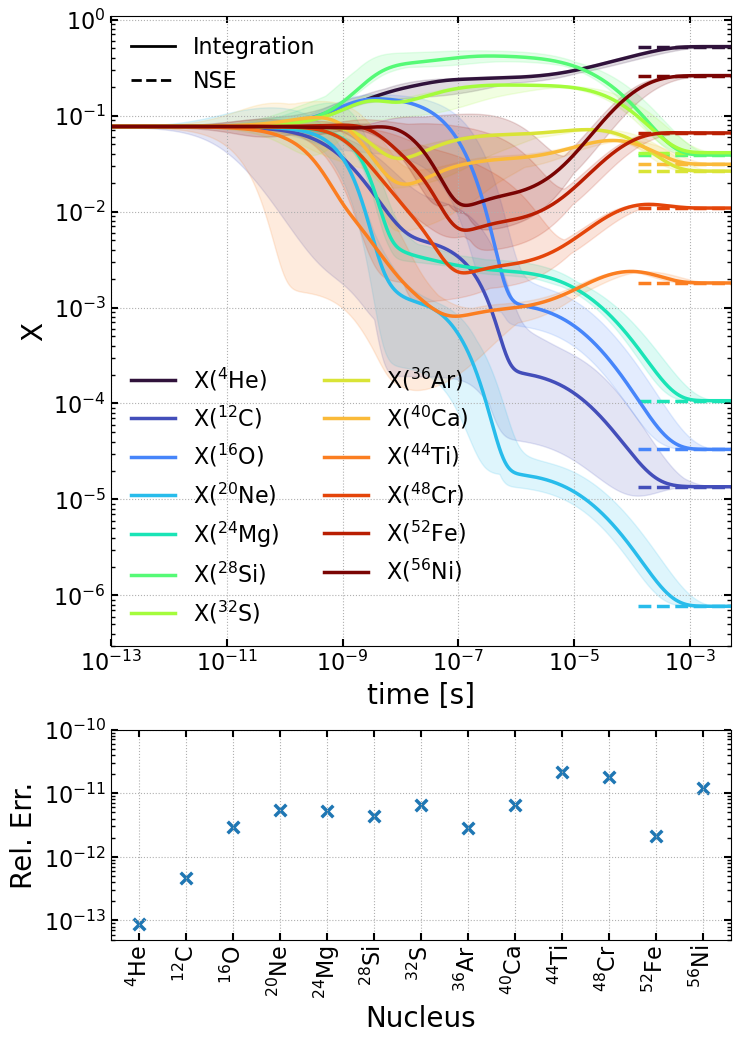

In [16]:
n_nuc = len(sl_sol.unique_nuclei)
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, n_nuc))
nuc_colors = {nuc: colors[i % len(colors)] for i, nuc in enumerate(sl_sol.unique_nuclei)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12), gridspec_kw={"height_ratios": [3.0, 1.0]})
nuc_labels = [rf"${nuc.pretty}$" for nuc in net.unique_nuclei]
    
X_net = sl_sol.X[:,-1]
X_nse = nse_comp.get_array()

# Plot horizontal dash lines to indicate NSE abundance.
for i, nuc in enumerate(sl_sol.unique_nuclei):
    ax1.axhline(y=X_nse[i], xmin=0.85, color=nuc_colors[nuc], linestyle="--")

for i, nuc in enumerate(sl_sol.unique_nuclei):
    ax1.fill_between(ts, X_min[i, :], X_max[i, :], color=nuc_colors[nuc], alpha=0.15)

# median StarLib rates
for i, nuc in enumerate(sl_sol.unique_nuclei):
    ax1.loglog(sl_sol.t, sl_sol.X[i, :],
              color=nuc_colors[nuc],
              label=f"X(${nuc.pretty}$)")

ax1.set_xlim(1.e-13, 5.e-3)
ax1.set_ylim(3.e-7, 1.1)
ax1.set_xlabel("time [s]")
ax1.set_ylabel("X")
ax1.tick_params(which="both", direction="in")
ax1.grid(ls=":")
style_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Integration"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="NSE"),
]
leg1 = ax1.legend(fontsize=16, ncol=2, frameon=False, loc="lower left")
ax1.add_artist(leg1)    # keep the first legend
ax1.legend(handles=style_handles, frameon=False, fontsize=16, loc="upper left")

# Relative Error plot
diff = np.abs(X_net - X_nse) 
diff_rel = diff / X_net
x = np.arange(len(net.unique_nuclei))

#tol = 1e-12
#ax2.axhline(tol, color="black")

#ax2.scatter(x, diff, marker ='o', color='tab:red', s=70)
ax2.scatter(x, diff_rel, marker ='x', color='tab:blue', s=70)
ax2.set_xlabel("Nucleus")
ax2.set_ylabel("Rel. Err.")
ax2.set_yscale("log")
ax2.grid(ls=":")
ax2.set_ylim([5e-14, 1e-10])
ax2.set_xticks(x, labels=nuc_labels, rotation=90)
ax2.yaxis.set_major_locator(FixedLocator([1e-13, 1e-12, 1e-11, 1e-10]))

for a in (ax1, ax2):
    a.minorticks_on()
    a.tick_params(top=True, bottom=True,
                  left=True, right=True,
                  direction="in", which="major")
    a.tick_params(top=False, bottom=False,
                  left=True, right=True,
                  direction="in", which="minor")

fig.savefig("nse-evolution.pdf", format="pdf", bbox_inches="tight")

We see machine-level precision between the steady state and NSE solutions.